In [10]:
# 安裝 SnowNLP 中文情感分析套件
#!pip install snownlp

# 匯入 SnowNLP 類別
from snownlp import SnowNLP

# 指定句子
sentence = "我很生氣"

# 使用 SnowNLP 進行情緒分析
s = SnowNLP(sentence)

# 輸出情緒分析結果
# s.sentiments 的結果為 0～1 之間的浮點數，越接近 1 表示越正面，越接近 0 表示越負面
print(f"情緒分數（0=負面，1=正面）：{s.sentiments}")


情緒分數（0=負面，1=正面）：0.39418533974882597


第 1 段 情緒分數：0.2773
第 2 段 情緒分數：1.0000
第 3 段 情緒分數：0.0000
第 4 段 情緒分數：0.9908
第 5 段 情緒分數：0.0000
第 6 段 情緒分數：0.5937
第 7 段 情緒分數：0.8532
第 8 段 情緒分數：0.9345
第 9 段 情緒分數：0.1069
第 10 段 情緒分數：1.0000


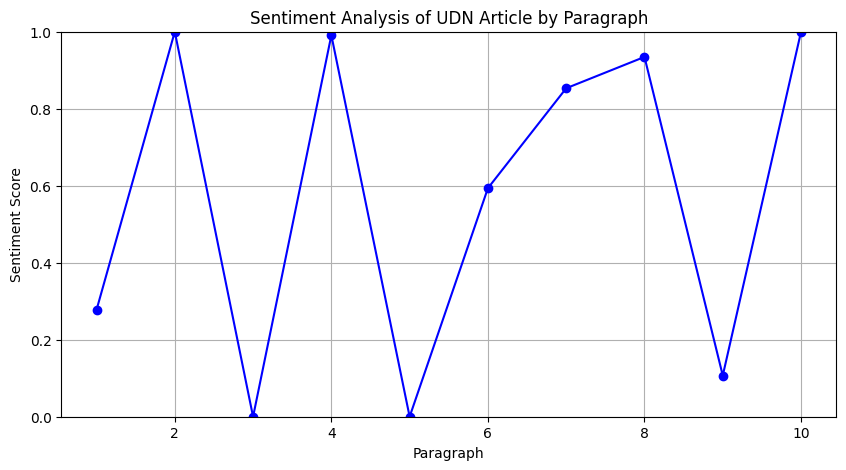

In [8]:


# 匯入套件
import requests
from bs4 import BeautifulSoup
from snownlp import SnowNLP
import matplotlib.pyplot as plt

# 取得網頁內容
url = "https://woman.udn.com/woman/story/123164/8748702?from=udn-listnews_ch4087"
response = requests.get(url)
response.encoding = 'utf-8'  # 設定編碼，避免亂碼

# 使用 BeautifulSoup 解析 HTML
soup = BeautifulSoup(response.text, 'html.parser')

# 擷取網頁中所有段落文字
# 這個範例是抓取 udn.com 特定新聞專題頁的文字內容
# 我們挑選有包含內容的 p 標籤
paragraphs = soup.find_all('p')

# 將段落文字合併成一整段文字，並去除多餘空白
text = '\n'.join(p.get_text().strip() for p in paragraphs if p.get_text().strip())

# 分段處理：將全文切分成 10 段（等長文字區段）
n_segments = 10
text_length = len(text)
segment_size = text_length // n_segments
segments = [text[i*segment_size : (i+1)*segment_size] for i in range(n_segments)]

# 使用 SnowNLP 對每段進行情緒分析
emotion_scores = [SnowNLP(segment).sentiments for segment in segments]

# 輸出每段的情緒分數
for idx, score in enumerate(emotion_scores):
    print(f"第 {idx+1} 段 情緒分數：{score:.4f}")

# 畫圖呈現情緒變化
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_segments+1), emotion_scores, marker='o', color='blue', linestyle='-')
plt.title("Sentiment Analysis of UDN Article by Paragraph")
plt.xlabel("Paragraph")
plt.ylabel("Sentiment Score")
plt.ylim(0, 1)
plt.grid(True)
plt.show()
